# Unpolarized fit: k-sector dominance

Read the generated inputs in `InputFiles/Generated/photo_k` and unpolarized fits in `OutputFiles/photo_k`, produced by `run-unpolarized-k-dominance-test.sh`.

The first section reports $(fit-generated)/generated$ for $R=\sigma_L/\sigma_T$ and each amplitude, using the quadrature of the generated $k=\pm1$ sectors. Repeated fits are summarized by the mean and standard error; undefined relative differences are omitted.

The Argand section shows the best fit within the file selected by $N$ and $M$: one colored fitted dot and two matching set-amplitude stars per wave, using each sector's own magnitude and phase.

In [15]:
import re
from pathlib import Path
from matplotlib.lines import Line2D

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ROOT

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "InputFiles").exists():
    PROJECT_DIR = PROJECT_DIR.parent

BATCH = None  # e.g. "N200" or "N200_M8"
INPUT_BASE = PROJECT_DIR / "InputFiles" / "Generated" / "photo_k"
FIT_BASE = PROJECT_DIR / "OutputFiles" / "photo_k"
FILE_RE = re.compile(r"^fixed_N(?P<n>\d+)(?:_M(?P<m>\d+))?_moments\.root$")
AMP_RE = re.compile(r"^(?P<wave>[ab]_[TL]_[^_]+_[^_]+)_(?P<k>m1|1)$")

inputs = {p.name: p for p in INPUT_BASE.iterdir() if p.is_dir()}
fits = {p.name: p for p in FIT_BASE.iterdir() if p.is_dir()}
batches = sorted(set(inputs) & set(fits))
if not batches:
    raise FileNotFoundError(f"No common batches under {INPUT_BASE} and {FIT_BASE}")
if BATCH is None:
    BATCH = max(
        batches,
        key=lambda b: max(
            (p.stat().st_mtime for p in inputs[b].glob("*.root")), default=0
        ),
    )

TRUTH_DIR, FIT_DIR = inputs[BATCH], fits[BATCH]
print(f"Batch: {BATCH}\nInput: {TRUTH_DIR}\nOutput: {FIT_DIR}")

Batch: N200
Input: /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter-refactored/InputFiles/Generated/photo_k/N200
Output: /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter-refactored/OutputFiles/photo_k/N200


In [16]:
# Best fit for each generated input, and its amplitude/R comparison.
def amplitude_ratio(values):
    transverse = sum(value**2 for wave, value in values.items()
                     if wave.split("_")[1] == "T")
    longitudinal = sum(
        (1 if wave.split("_")[3] == "0" else 2) * value**2
        for wave, value in values.items() if wave.split("_")[1] == "L"
    )
    return longitudinal / transverse if transverse > 1e-12 else np.nan


rows, evaluated, missing, best_fits = [], [], [], []
input_files = sorted(TRUTH_DIR.glob("fixed_N*_moments.root"))
for input_file in input_files:
    match = FILE_RE.match(input_file.name)
    if not match:
        continue
    m, repeat = int(match["m"] or 0), int(match["n"])
    output_file = FIT_DIR / input_file.name.replace("_moments.root", "_unpolarized_fit.root")
    if not output_file.exists():
        missing.append(output_file.name)
        continue

    truth_root, fit_root = None, None
    try:
        truth_root = ROOT.TFile.Open(str(input_file))
        fit_root = ROOT.TFile.Open(str(output_file))
        if not truth_root or truth_root.IsZombie() or not fit_root or fit_root.IsZombie():
            raise RuntimeError(f"Could not open ROOT pair for {input_file.name}")
        truth = truth_root.Get("genMoments")
        fit = fit_root.Get("fitResults")
        if not truth or not fit:
            raise RuntimeError(f"Missing required tree in ROOT pair for {input_file.name}")
        if truth.GetEntries() == 0:
            continue

        truth_names = [branch.GetName() for branch in truth.GetListOfBranches()]
        fit_names = {branch.GetName() for branch in fit.GetListOfBranches()}
        generated = {}
        for name in truth_names:
            found = AMP_RE.match(name)
            if found:
                generated.setdefault(found["wave"], {})[found["k"]] = name
        waves = sorted(
            wave for wave, sectors in generated.items()
            if {"m1", "1"} <= sectors.keys() and wave in fit_names
        )
        if not waves:
            continue

        truth.GetEntry(0)
        quadrature = {
            wave: np.hypot(
                float(getattr(truth, generated[wave]["1"])),
                float(getattr(truth, generated[wave]["m1"])),
            )
            for wave in waves
        }

        # Keep finite minima even if a covariance/Hesse step made fit_ok false.
        accepted = []
        for entry in range(fit.GetEntries()):
            fit.GetEntry(entry)
            chi2 = float(fit.chi2) if "chi2" in fit_names else np.nan
            if "chi2" not in fit_names or np.isfinite(chi2):
                accepted.append((chi2, entry))
        if not accepted:
            continue
        chi2, best_entry = min(accepted)
        fit.GetEntry(best_entry)
        fitted_values = {wave: abs(float(getattr(fit, wave))) for wave in waves}
        best_fits.append({
            "M": m, "repeat": repeat, "chi2": chi2, "entry": best_entry,
            "input_file": input_file, "output_file": output_file, "waves": waves,
        })

        for wave in waves:
            evaluated.append({
                "M": m, "repeat": repeat, "wave": wave,
                "generated_quadrature": quadrature[wave],
                "fit_magnitude": fitted_values[wave],
            })
            if quadrature[wave] > 1e-12:
                rows.append({
                    "M": m, "repeat": repeat, "observable": "amplitude", "wave": wave,
                    "relative_difference": (fitted_values[wave] - quadrature[wave]) / quadrature[wave],
                })

        truth_R = amplitude_ratio(quadrature)
        fit_R = amplitude_ratio(fitted_values)
        if np.isfinite(truth_R) and abs(truth_R) > 1e-12 and np.isfinite(fit_R):
            rows.append({
                "M": m, "repeat": repeat, "observable": "R", "wave": "R",
                "relative_difference": (fit_R - truth_R) / truth_R,
            })
    finally:
        if truth_root:
            truth_root.Close()
        if fit_root:
            fit_root.Close()

if not evaluated:
    raise RuntimeError(
        f"No generated/fit pairs were successfully read from {TRUTH_DIR} and {FIT_DIR}; "
        f"checked {len(input_files)} inputs, found {len(missing)} missing outputs"
    )
data = pd.DataFrame(rows, columns=["M", "repeat", "observable", "wave", "relative_difference"])
evaluated = pd.DataFrame(evaluated)

In [17]:
# Repeated-fit summaries.
print("Evaluated amplitudes (including zero-valued branches):")
print(
    evaluated.groupby(["M", "wave"])[["generated_quadrature", "fit_magnitude"]]
    .mean().to_string(float_format=lambda value: f"{value:.6g}")
)

summary = (
    data.groupby(["M", "observable", "wave"])["relative_difference"]
    .agg(mean="mean", stderr=lambda values: values.std(ddof=1) / np.sqrt(values.count()),
         samples="count")
    .reset_index()
)
print(summary.to_string(index=False, float_format=lambda value: f"{value:.6g}"))
if missing:
    print(f"\nMissing fit files: {len(missing)}")

Evaluated amplitudes (including zero-valued branches):
            generated_quadrature  fit_magnitude
M wave                                         
0 a_T_0_0               0.253704       0.177208
  a_T_1_0               0.180972       0.177469
  a_T_1_1               0.861995       0.851242
  a_T_1_m1                     0      0.0523439
  b_T_0_0                      0       0.224881
  b_T_1_0               0.195776       0.111599
  b_T_1_1                   0.25       0.196403
  b_T_1_m1              0.237366       0.236733
 M observable     wave       mean     stderr  samples
 0  amplitude  a_T_0_0  -0.299207  0.0202681      200
 0  amplitude  a_T_1_0 -0.0167382  0.0153112      200
 0  amplitude  a_T_1_1 -0.0125253 0.00149844      200
 0  amplitude  b_T_1_0  -0.432775  0.0271606      200
 0  amplitude  b_T_1_1  -0.214389  0.0253172      200
 0  amplitude b_T_1_m1 -0.0115837  0.0156116      200


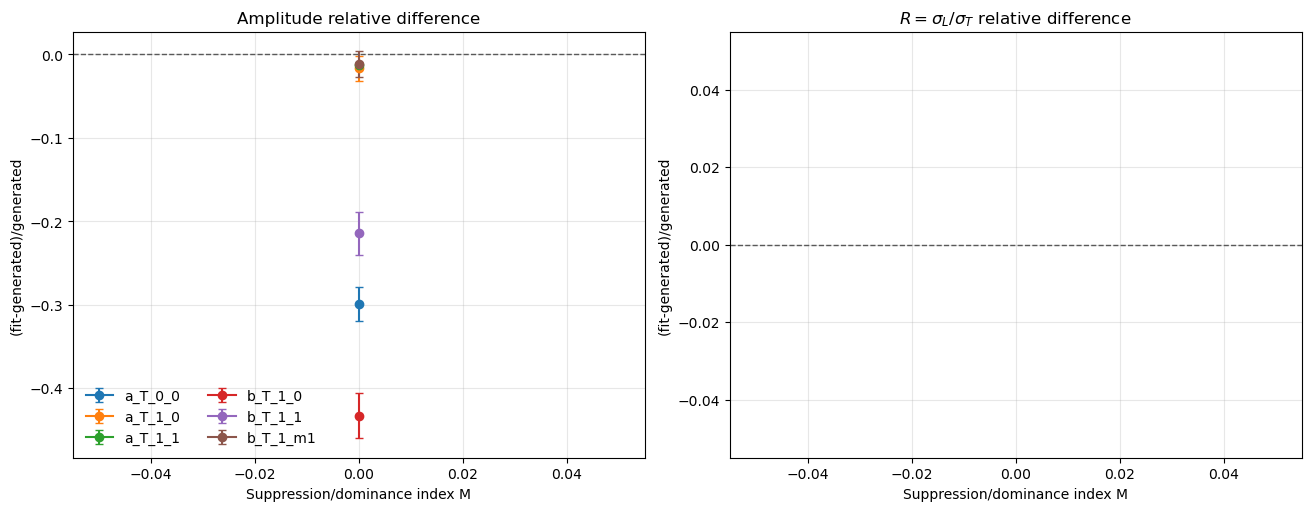

In [18]:
# Relative differences across suppression/dominance settings.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for wave, group in summary[summary.observable == "amplitude"].groupby("wave"):
    axes[0].errorbar(
        group.M, group["mean"], yerr=group.stderr,
        marker="o", capsize=3, label=wave,
    )
r = summary[summary.observable == "R"]
axes[1].errorbar(r.M, r["mean"], yerr=r.stderr, marker="o", capsize=3, color="black")
titles = ["Amplitude relative difference", r"$R=\sigma_L/\sigma_T$ relative difference"]
for axis, title in zip(axes, titles):
    axis.axhline(0, color="0.35", linestyle="--", linewidth=1)
    axis.set(
        xlabel="Suppression/dominance index M",
        ylabel="(fit-generated)/generated", title=title,
    )
    axis.grid(alpha=0.3)
axes[0].legend(frameon=False, ncol=2)
plt.show()

## Set and fitted amplitudes

Choose the file repeat index $N$ and suppression/dominance index $M$. Plot that file's lowest finite $\chi^2$ fit with its paired generated amplitudes. Both $k$ sectors are stars in the fitted wave's color; coincident stars overlap. Zero-valued waves are included.

In [19]:
# Same labels and poster style as fixed_amp_analysis.
def ToWave(name):
    refl, pol, ell, m = name.split("_")
    sign = "+" if refl == "a" else "-"
    wave = ["S", "P", "D"][int(ell)]
    m = m.replace("m", "-")
    return wave + "$^" + sign + r"_{\mathrm{" + pol + "}" + m + "}$"


def apply_poster_axis_style(ax, labelsize=20):
    ax.tick_params(axis="both", which="major", labelsize=labelsize, width=2.0, length=8, pad=6)
    ax.tick_params(axis="both", which="minor", width=1.6, length=5)
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)


poster_style = {
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 36,
    "axes.titlesize": 42,
    "axes.labelsize": 40,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 34,
    "lines.linewidth": 4.0,
    "axes.linewidth": 2.8,
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,
    "xtick.minor.size": 6,
    "ytick.minor.size": 6,
    "savefig.dpi": 300,
}

In [23]:
N = 26  # File repeat index (fixed_N...); not the batch size.
M = 0  # Suppression/dominance index to plot.
candidates = [result for result in best_fits
              if result["repeat"] == N and result["M"] == M and np.isfinite(result["chi2"])]
if not candidates:
    raise ValueError(f"No finite-chi2 fit for N={N}, M={M} in batch {BATCH}")
selected_fit = candidates[0]  # Already the lowest-chi2 entry for this file.
print(f"Input: {selected_fit['input_file'].name}")
print(f"Fit: {selected_fit['output_file'].name}")
print(f"Entry: {selected_fit['entry']}, chi2: {selected_fit['chi2']:.6g}")

wave_rows = []
truth_root, fit_root = None, None
try:
    truth_root = ROOT.TFile.Open(str(selected_fit["input_file"]))
    fit_root = ROOT.TFile.Open(str(selected_fit["output_file"]))
    if not truth_root or truth_root.IsZombie() or not fit_root or fit_root.IsZombie():
        raise RuntimeError("Could not open selected ROOT pair")
    truth = truth_root.Get("genMoments")
    fit = fit_root.Get("fitResults")
    truth.GetEntry(0)
    fit.GetEntry(selected_fit["entry"])

    for wave in sorted(
        selected_fit["waves"],
        key=lambda name: (int(name.split("_")[2]), -int(name.split("_")[3].replace("m", "-"))),
    ):
        phase_name = wave[0] + "phi" + wave[1:]
        wave_rows.append({
            "wave": wave,
            "group": tuple(wave.split("_")[:2]),
            "mag": float(getattr(fit, wave)),
            "phase": float(getattr(fit, phase_name)),
            "truth_mag": np.array([float(getattr(truth, wave + "_" + k)) for k in ("1", "m1")]),
            "truth_phase": np.array([float(getattr(truth, phase_name + "_" + k)) for k in ("1", "m1")]),
        })
finally:
    if truth_root:
        truth_root.Close()
    if fit_root:
        fit_root.Close()

Input: fixed_N26_moments.root
Fit: fixed_N26_unpolarized_fit.root
Entry: 581, chi2: 0.000213928


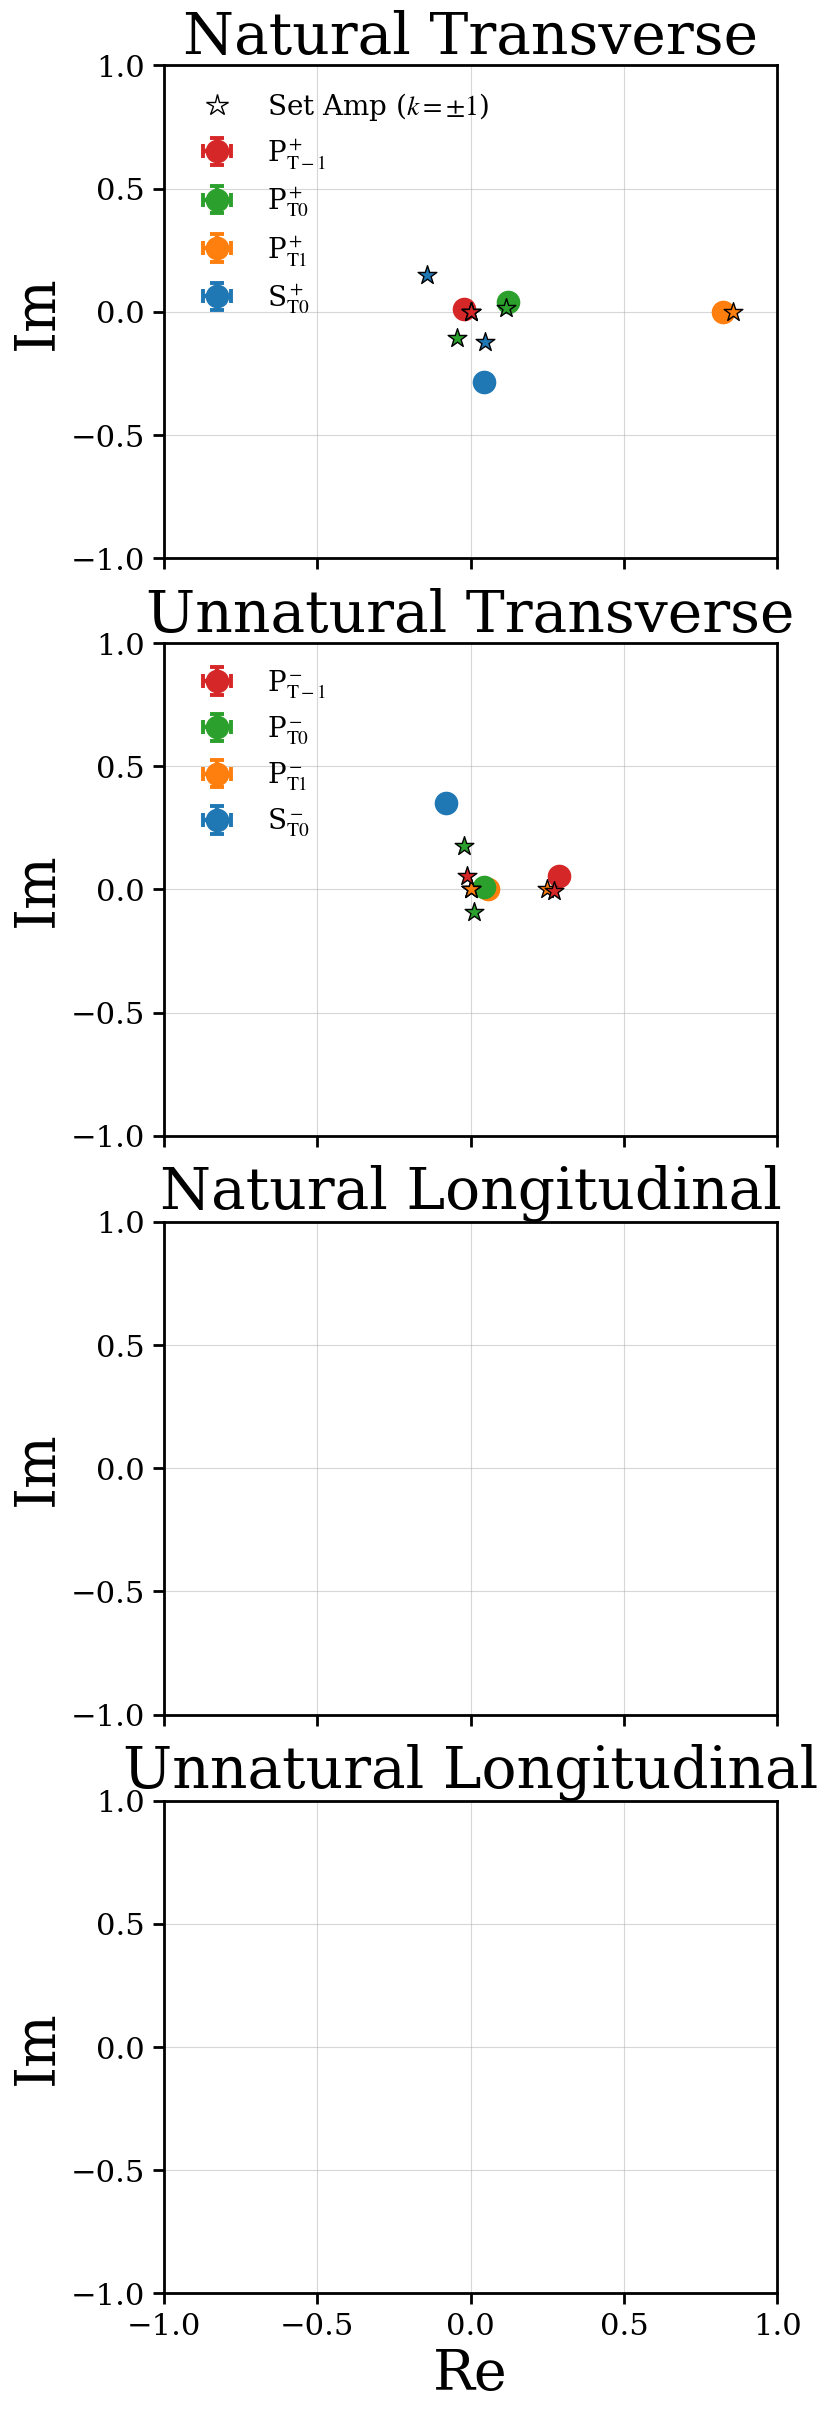

In [24]:
group_defs = [
    (("a", "T"), "Natural Transverse"),
    (("b", "T"), "Unnatural Transverse"),
    (("a", "L"), "Natural Longitudinal"),
    (("b", "L"), "Unnatural Longitudinal"),
]

with plt.rc_context(poster_style):
    fig, axs = plt.subplots(4, 1, figsize=(8, 24), sharex=True, constrained_layout=True)
    for j, (group_key, title) in enumerate(group_defs):
        for row in wave_rows:
            if row["group"] != group_key:
                continue

            mag, phase = row["mag"], row["phase"]
            tru_mag, tru_phase = row["truth_mag"], row["truth_phase"]
            dot = axs[j].errorbar(
                mag * np.cos(phase), mag * np.sin(phase),
                xerr=0, yerr=0,
                fmt="o", markersize=16, elinewidth=3.2,
                capsize=5, capthick=2.8, label=ToWave(row["wave"]),
            )
            clr = dot.lines[0].get_color()
            axs[j].scatter(
                tru_mag * np.cos(tru_phase), tru_mag * np.sin(tru_phase),
                zorder=5, marker="*", s=200, color=clr, edgecolors="black",
            )

        axs[j].axis(xmin=-1, xmax=1, ymin=-1, ymax=1)
        axs[j].set_ylabel("Im")
        if j == 3:
            axs[j].set_xlabel("Re")
        axs[j].set_title(title)
        axs[j].set_yticks([-1, -0.5, 0, 0.5, 1])
        axs[j].set_xticks([-1, -0.5, 0, 0.5, 1])
        axs[j].grid(True, alpha=0.5)
        handles, labels = axs[j].get_legend_handles_labels()
        if j == 0:
            handles.append(Line2D(
                [0], [0], label=r"Set Amp ($k=\pm1$)", marker="*", markersize=16,
                markeredgecolor="black", markerfacecolor="white", linestyle="",
            ))
        if handles:
            axs[j].legend(handles=handles, loc="upper left", frameon=False, fontsize=20, reverse=True)
        apply_poster_axis_style(axs[j], labelsize=22)
    plt.show()

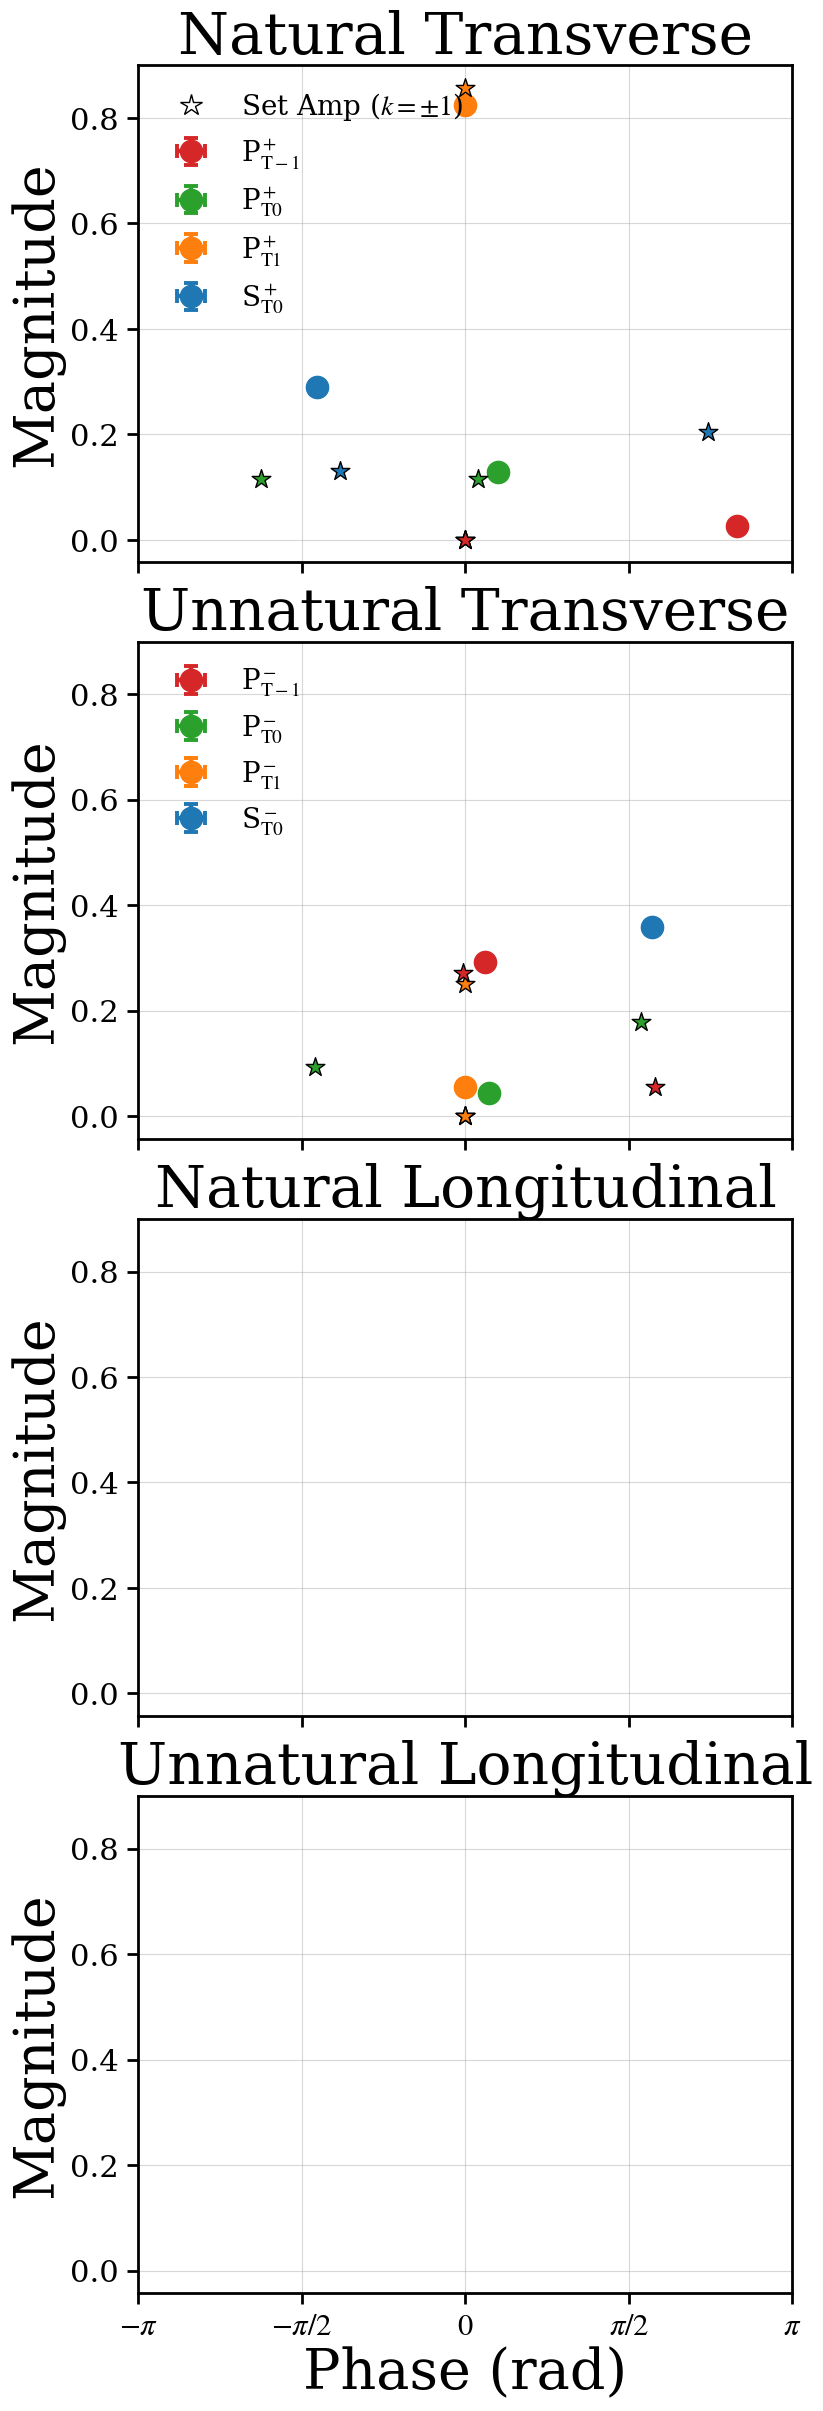

In [25]:
# The same amplitudes, shown as magnitude versus phase.
with plt.rc_context(poster_style):
    fig_mag_phase, axs_mag_phase = plt.subplots(
        4, 1, figsize=(8, 24), sharex=True, sharey=True, constrained_layout=True
    )
    for j, (group_key, title) in enumerate(group_defs):
        for row in wave_rows:
            if row["group"] != group_key:
                continue

            mag, phase = row["mag"], row["phase"]
            tru_mag, tru_phase = row["truth_mag"], row["truth_phase"]
            # Positive magnitudes with equivalent phases in [-pi, pi).
            phase = (phase + (np.pi if mag < 0 else 0) + np.pi) % (2 * np.pi) - np.pi
            tru_phase = (tru_phase + np.where(tru_mag < 0, np.pi, 0) + np.pi) % (2 * np.pi) - np.pi

            dot = axs_mag_phase[j].errorbar(
                phase, abs(mag),
                xerr=0, yerr=0,
                fmt="o", markersize=16, elinewidth=3.2,
                capsize=5, capthick=2.8, label=ToWave(row["wave"]),
            )
            clr = dot.lines[0].get_color()
            axs_mag_phase[j].scatter(
                tru_phase, np.abs(tru_mag),
                zorder=5, marker="*", s=200, color=clr, edgecolors="black",
            )

        axs_mag_phase[j].set_xlim(-np.pi, np.pi)
        axs_mag_phase[j].set_ylabel("Magnitude")
        if j == 3:
            axs_mag_phase[j].set_xlabel("Phase (rad)")
        axs_mag_phase[j].set_title(title)
        axs_mag_phase[j].set_xticks(
            [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
            [r"$-\pi$", r"$-\pi/2$", "$0$", r"$\pi/2$", r"$\pi$"],
        )
        axs_mag_phase[j].grid(True, alpha=0.5)
        handles, labels = axs_mag_phase[j].get_legend_handles_labels()
        if j == 0:
            handles.append(Line2D(
                [0], [0], label=r"Set Amp ($k=\pm1$)", marker="*", markersize=16,
                markeredgecolor="black", markerfacecolor="white", linestyle="",
            ))
        if handles:
            axs_mag_phase[j].legend(
                handles=handles, loc="upper left", frameon=False, fontsize=20, reverse=True
            )
        apply_poster_axis_style(axs_mag_phase[j], labelsize=22)
    plt.show()